
### **Chapter 6.3: Gaussian Process Model Predictive Control**

Chapter 6.2 ended with a learned probabilistic model: a posterior mean for the terrain together with a variance describing how far that mean can be trusted. This chapter puts such a model into the loop and asks the question that matters for control: what does the variance actually buy?

A learned probabilistic model predicts one step ahead. A predictive controller needs a whole trajectory, so the uncertainty attached to a single step has to be **propagated over the prediction horizon** and then converted into something the optimizer can use. The standard route is to tighten the state constraints in proportion to the propagated uncertainty, which turns a chance constraint into a deterministic one. This chapter builds that controller around a Gaussian process (GP) model and studies two questions:

- **How much uncertainty should we plan against?** A controller that trusts its learned mean completely violates the constraint; one that tightens too aggressively becomes slow. The confidence level is a design knob with a measurable cost.

- **What happens when the variance itself is wrong?** Constraint tightening is only as trustworthy as the uncertainty estimate driving it. If the model reports too little uncertainty, no amount of tightening restores safety.

The task is the mountain car of Chapter 6.2 on the same bumpy terrain, but with a **speed limit that is actually active**: the controller would like to travel at roughly 0.77 m/s and is allowed 0.6 m/s. Data is collected everywhere except an unexplored gap in the middle of the domain, so the learned model is confident at the edges and ignorant in the middle, and the controller must cross that gap while respecting the limit.

<style>
  table td:nth-child(2) {
    text-align: left;
  }
</style>

<table border="1" style="border-collapse: collapse;">  <!-- Title Row -->
  <tr>
    <th colspan="2" style="text-align:center">Chapter 6.3</th>
  </tr>
  <tr>
    <td rowspan="2">Gaussian Process MPC</td>
    <td>Example 1.1: Certainty-Equivalent Control versus Constraint Tightening</td>
  </tr>
  <tr>
    <td>Example 1.2: When the Uncertainty Estimate Is Miscalibrated</td>
  </tr>
</table>

<br>

First, we set up the Python environment and import the relevant packages.


In [1]:
import sys
import os
import numpy as np
import casadi as ca
import scipy.linalg
import matplotlib.pyplot as plt
from acados_template import AcadosModel, AcadosOcp, AcadosOcpSolver

# Put the repository root at the FRONT of sys.path. A sibling repository on this
# machine also contains packages named `utils` and `ex6_SysID`, and it can appear on
# sys.path ahead of us (for instance when the kernel points straight at its virtual
# environment). Appending would let it win and the imports below would silently
# resolve to the wrong files; inserting at position 0 makes this repository win.
repo_root = os.path.abspath("..")
if repo_root in sys.path:
    sys.path.remove(repo_root)
sys.path.insert(0, repo_root)
from utils.env import *
from utils.simulator import *
from ex2_LQR.lqr_utils import *
from ex5_MPC.mpc_utils import *
from ex6_SysID.SysID_utils import *

<br>

----

### **Experimental Setup**

The plant is the bumpy terrain $h(p) = k\cos(18p)$ with $k = 0.01$ (case 3), exactly as in Chapter 6.2. What changes is the constraint set. In Chapter 6.2 the state bounds were $p \in [-2, 2]$ and $v \in [-4, 4]$, and the closed-loop trajectory peaked at $|v| \approx 0.77$, so no state constraint was ever active and constraint tightening had nothing to do. Here we impose

$$
v \le v_{\max} = 0.6 ,
$$

which the nominal controller would like to violate. Everything the tightening does is now visible in the trajectory.

- Task: $\boldsymbol{x}_0 = [-0.5, 0]^\top$, $\boldsymbol{x}_T = [0.5, 0]^\top$, horizon $N = 20$, control frequency 10 Hz, 8 s of simulation.

- Constraints: $p \in [-2, 2]$, $v \in [-0.6, 0.6]$, $a \in [-8, 8]$.

- Costs: $\boldsymbol{Q} = \text{diag}([5,5])$, $R = 0.1$, $\boldsymbol{Q}_f = \boldsymbol{Q}$.

- Data: 150 samples on $p \in [-2,-0.5] \cup [0.5, 2]$, measurement noise $\sigma = 0.005$, no data on $p \in [-0.5, 0.5]$.


In [2]:
# Real environment
case_real = 3
terrain_param = 0.01

# Task
initial_position, initial_velocity = -0.5, 0.0
target_position, target_velocity = 0.5, 0.0
x0 = np.array([initial_position, initial_velocity])
xT = np.array([target_position, target_velocity])

# Constraints. The speed limit is the constraint of interest: the nominal controller
# would like to travel at about 0.77 m/s, so 0.6 m/s is active and must be respected.
v_max = 0.6
state_lbs = np.array([-2.0, -v_max])
state_ubs = np.array([ 2.0,  v_max])
input_lbs, input_ubs = -8.0, 8.0

# Controller
N = 20
Q = np.diag([5, 5])
R = np.array([[0.1]])
Qf = Q

# Simulation
freq = 10
t_terminal = 8

# Data collection: measurements everywhere except an unexplored gap
gap = (-0.5, 0.5)
num_samples = 150
sigma_meas = 0.005

# The true system, used only to simulate the plant
env_real = Env(case_real, x0, xT, param=terrain_param, state_lbs=state_lbs,
               state_ubs=state_ubs, input_lbs=input_lbs, input_ubs=input_ubs)
dynamics_real = Dynamics(env_real)

<br>

----

### **The Learned Model and the Quantity the Controller Needs**

We fit a GP with a squared-exponential kernel and hyperparameters tuned by maximizing the log marginal likelihood, exactly as in Chapter 6.2, and then convert it into CasADi expressions so that it can be embedded in the optimal control problem.

The controller needs three things from the model, and the third is easy to get wrong. The dynamics

$$
\dot p = v, \qquad \dot v = u\cos\theta(p) - g\sin\theta(p)\cos\theta(p)
$$

depend on the terrain **only through the inclination** $\theta(p) = \arctan\big(h'(p)\big)$. What propagates into the process noise is therefore the uncertainty of the *slope*, $\mathrm{Var}[h'(p)]$, and not the uncertainty of the height, $\mathrm{Var}[h(p)]$. These are different objects, and the first cannot be recovered from the second: it is the second mixed derivative of the posterior covariance,

$$
\mathrm{Var}[h'(p)] = \frac{\partial^2}{\partial p \, \partial p'} \, \mathrm{Cov}\big[h(p), h(p')\big] \Big|_{p' = p},
$$

which for the squared-exponential kernel evaluates to $\sigma_f^2/\ell^2 - (\partial_p k_*)^\top K^{-1} (\partial_p k_*)$. Differentiating the marginal variance with respect to $p$ would give a different, signed quantity. `construct_gp_casadi_expression` returns all three functions.


GP hyperparameters from marginal likelihood: lengthscale = 0.0780, signal std = 0.00757


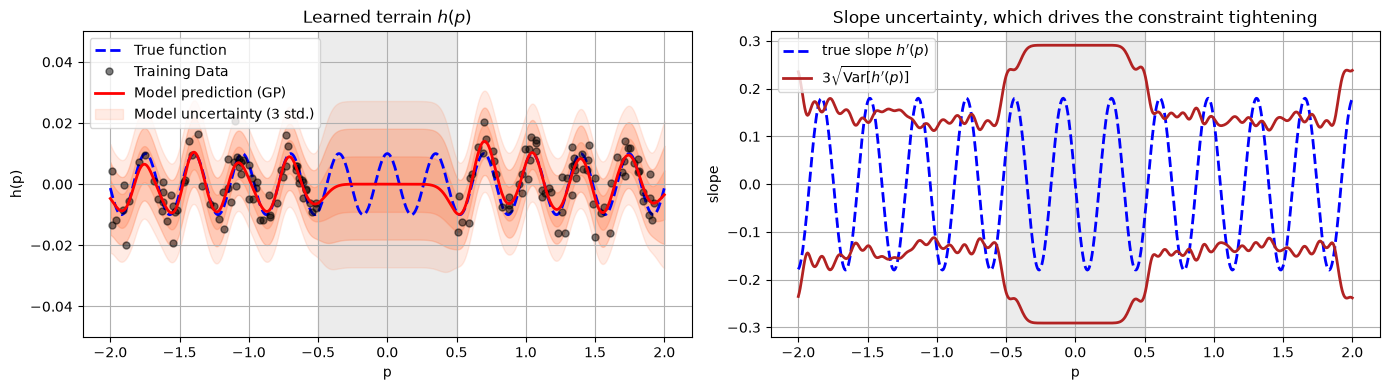

slope std where data is dense: 0.0467
slope std inside the gap     : 0.0970


In [3]:
# Collect data with a gap, and fit a GP whose hyperparameters are tuned by marginal likelihood
np.random.seed(49) # for reproducibility
data_gen = GenerateData(p_range=[(-2.0, gap[0]), (gap[1], 2.0)], num_samples=num_samples,
                        case=case_real, param=terrain_param)
data_gen.set_noise(mean=0.0, std=sigma_meas)
p_train, h_train = data_gen.generate_data()

model_gp = Identifier_GP(noise_std=sigma_meas)
(l_opt, sf_opt), _ = model_gp.optimize_hyperparameters(p_train, h_train)
model_gp.fit(p_train, h_train)
print(f"GP hyperparameters from marginal likelihood: lengthscale = {l_opt:.4f}, signal std = {sf_opt:.5f}")

# Convert to CasADi so the model can be used inside the MPC
h_gp, sigma2_h_gp, sigma2_dh_gp = construct_gp_casadi_expression(model_gp)

# Inspect the two quantities the controller needs
p_test = np.linspace(-2.0, 2.0, 601).reshape(-1, 1)
true_func = data_gen.get_symbolic_function()
std_slope = np.array([np.sqrt(float(sigma2_dh_gp(p))) for p in p_test.ravel()])
true_slope = -terrain_param * 18 * np.sin(18 * p_test.ravel())

_, axes = plt.subplots(1, 2, figsize=(14, 4))
model_gp.plot(p_test=p_test, true_func=true_func, ax=axes[0])
axes[0].set_title("Learned terrain $h(p)$")
axes[0].set_ylim(-0.05, 0.05)

axes[1].plot(p_test, true_slope, 'b--', linewidth=2, label="true slope $h'(p)$")
axes[1].plot(p_test, 3 * std_slope, color='firebrick', linewidth=2, label=r"$3\sqrt{\mathrm{Var}[h'(p)]}$")
axes[1].plot(p_test, -3 * std_slope, color='firebrick', linewidth=2)
axes[1].set_xlabel("p"); axes[1].set_ylabel("slope"); axes[1].grid(True); axes[1].legend()
axes[1].set_title("Slope uncertainty, which drives the constraint tightening")
for ax in axes:
    ax.axvspan(gap[0], gap[1], color='gray', alpha=0.15, zorder=0)
plt.tight_layout(); plt.show()

print(f"slope std where data is dense: {np.sqrt(float(sigma2_dh_gp(-1.2))):.4f}")
print(f"slope std inside the gap     : {np.sqrt(float(sigma2_dh_gp(0.0))):.4f}")

<br>

----

### **Stochastic MPC with a Learned Model**

Because the learned model predicts one step at a time, the controller has to carry a state distribution forward itself. Starting from the measured state, with $\boldsymbol{\Sigma}^x_{0|k} = \boldsymbol{0}$, we roll the mean forward through the learned dynamics and propagate the covariance by linearization,

$$
\boldsymbol{\Sigma}^x_{i+1|k} = \boldsymbol{A}_i \, \boldsymbol{\Sigma}^x_{i|k} \, \boldsymbol{A}_i^\top + \boldsymbol{\Sigma}^w\!\left(\boldsymbol{\mu}^x_{i|k}, \boldsymbol{u}_{i|k}\right),
$$

where $\boldsymbol{A}_i$ is the discrete-time Jacobian of the learned dynamics and $\boldsymbol{\Sigma}^w$ is obtained by pushing $\mathrm{Var}[h'(p)]$ through the dynamics. The first term makes uncertainty accumulate along the horizon; the second injects fresh model uncertainty at each step, and it is large exactly where the GP has no data.

The chance constraint $\mathbb{P}\big(\boldsymbol{x}_{i|k} \in \mathcal{X}\big) \ge \alpha$ is then replaced by the deterministic tightening

$$
\underline{\boldsymbol{x}} + \beta \sqrt{\mathrm{diag}\,\boldsymbol{\Sigma}^x_{i|k}} \;\le\; \boldsymbol{\mu}^x_{i|k} \;\le\; \overline{\boldsymbol{x}} - \beta \sqrt{\mathrm{diag}\,\boldsymbol{\Sigma}^x_{i|k}},
$$

with $\beta$ selected from the confidence level under a Gaussian assumption ($\beta = 2$ is roughly $95\%$ per constraint). Setting $\beta = 0$ recovers a **certainty-equivalent** controller that uses the learned mean and ignores its uncertainty.

The state constraints are implemented as soft constraints with a large penalty. This is deliberate: an over-tightened problem then remains solvable and reports a violation, rather than failing to solve and leaving us unable to distinguish "too conservative" from "broken".
Two implementation details matter enough to be explicit about. First, the propagation uses an **ancillary feedback**: the open-loop linearization of the car on a bump has eigenvalues of roughly $\pm 5.6$, so an open-loop recursion $\boldsymbol{A}_i\boldsymbol{\Sigma}_i\boldsymbol{A}_i^\top$ amplifies the covariance by about four orders of magnitude over a 2 s horizon and predicts nothing useful. The predicted state is not open loop, since the controller keeps acting, so we propagate under $\boldsymbol{A}_i + \boldsymbol{B}_i\boldsymbol{K}$ with $\boldsymbol{K}$ an LQR gain, as is standard in tube- and covariance-based MPC. Second, the tightened box is never allowed to shrink below a fixed fraction of its original width, and the number of times that cap binds is reported, so that an unattainable confidence level is visible rather than silently clipped.


In [4]:
class GPMPCController(LQRController):
    """
    Stochastic MPC using a learned probabilistic model.

    At each step the controller
      1. rolls out the predicted mean trajectory using the learned mean dynamics,
      2. propagates the state covariance along that trajectory,
             Sigma_{i+1} = A_i Sigma_i A_i^T + Sigma^w(mu_i, u_i),
         where A_i is the discrete-time Jacobian of the learned dynamics, and
      3. tightens the state constraints by beta standard deviations,
             lb + beta*sqrt(diag(Sigma_i))  <=  x_i  <=  ub - beta*sqrt(diag(Sigma_i)),
         which is the deterministic reformulation of a chance constraint under a
         Gaussian assumption (beta = 2 corresponds to roughly 95% per constraint).

    Setting beta = 0 recovers a certainty-equivalent MPC that uses the learned mean
    and ignores its uncertainty.
    """

    def __init__(self, env, dynamics, Q, R, Qf, N, freq, beta=2.0,
                 Sigma_w=None, name='GPMPC', type='MPC', verbose=False):
        self.Qf = Qf
        self.N = N
        self.beta = beta
        super().__init__(env, dynamics, Q, R, freq, name, type, verbose)
        if self.env.dh_cov is None:
            raise ValueError("GP-MPC needs env.dh_cov, the variance of the terrain slope.")
        self.dynamics.build_stochastic_model(self.dt)
        self.Sigma_w = Sigma_w if Sigma_w is not None else np.zeros((self.dim_states, self.dim_states))
        self.Sigma_x_log = []
        self.n_saturated = 0
        self.K_ancillary = self._ancillary_gain()

    def setup(self):
        model = AcadosModel()
        model.name = self.name
        model.x = self.dynamics.states
        model.u = self.dynamics.inputs
        model.f_expl_expr = ca.vertcat(self.dynamics.dynamics_function(self.dynamics.states, self.dynamics.inputs))
        model.f_impl_expr = None

        ocp = AcadosOcp()
        ocp.model = model
        ocp.dims.N = self.N
        ocp.solver_options.tf = self.N * self.dt
        ocp.solver_options.qp_solver = "FULL_CONDENSING_HPIPM"
        ocp.solver_options.integrator_type = "ERK"
        ocp.solver_options.nlp_solver_type = "SQP"
        ocp.solver_options.nlp_solver_max_iter = 100

        ocp.cost.cost_type = "LINEAR_LS"
        ocp.cost.cost_type_e = "LINEAR_LS"
        ocp.cost.W = np.block([[self.Q, np.zeros((self.dim_states, self.dim_inputs))],
                               [np.zeros((self.dim_inputs, self.dim_states)), self.R]])
        ocp.cost.W_e = self.Qf
        ocp.cost.Vx = np.block([[np.eye(self.dim_states)], [np.zeros((self.dim_inputs, self.dim_states))]])
        ocp.cost.Vu = np.block([[np.zeros((self.dim_states, self.dim_inputs))], [np.eye(self.dim_inputs)]])
        ocp.cost.Vx_e = np.eye(self.dim_states)
        ocp.cost.yref = np.zeros(self.dim_states + self.dim_inputs)
        ocp.cost.yref_e = np.zeros(self.dim_states)

        # State constraints are softened so that an over-tightened problem stays
        # feasible and reports a violation instead of failing to solve.
        ocp.constraints.idxbx_0 = np.arange(self.dim_states)
        ocp.constraints.idxbx = np.arange(self.dim_states)
        ocp.constraints.idxbx_e = np.arange(self.dim_states)
        ocp.constraints.idxbu = np.arange(self.dim_inputs)
        ocp.constraints.lbx_0 = np.array(self.env.state_lbs)
        ocp.constraints.ubx_0 = np.array(self.env.state_ubs)
        ocp.constraints.lbx = np.array(self.env.state_lbs)
        ocp.constraints.ubx = np.array(self.env.state_ubs)
        ocp.constraints.lbx_e = np.array(self.env.state_lbs)
        ocp.constraints.ubx_e = np.array(self.env.state_ubs)
        ocp.constraints.lbu = np.array(self.env.input_lbs)
        ocp.constraints.ubu = np.array(self.env.input_ubs)

        ocp.constraints.idxsbx = np.arange(self.dim_states)
        ocp.constraints.idxsbx_e = np.arange(self.dim_states)
        ns, ns_e = self.dim_states, self.dim_states
        ocp.cost.Zl = 1e4 * np.ones(ns);   ocp.cost.Zu = 1e4 * np.ones(ns)
        ocp.cost.zl = 1e2 * np.ones(ns);   ocp.cost.zu = 1e2 * np.ones(ns)
        ocp.cost.Zl_e = 1e4 * np.ones(ns_e); ocp.cost.Zu_e = 1e4 * np.ones(ns_e)
        ocp.cost.zl_e = 1e2 * np.ones(ns_e); ocp.cost.zu_e = 1e2 * np.ones(ns_e)

        self.ocp = ocp
        self.solver = AcadosOcpSolver(ocp, json_file=f"{self.name}.json", verbose=False)

    def _ancillary_gain(self):
        """
        LQR gain used only inside the uncertainty propagation.

        The open-loop dynamics of the car are unstable on the bumps: linearizing on a
        crest gives eigenvalues of roughly +-5.6, so over a 2 s horizon an open-loop
        propagation A_i Sigma_i A_i^T amplifies the covariance by four orders of
        magnitude and the predicted uncertainty is meaningless. The predicted state is
        not actually open loop, however, since the controller will keep acting. We
        therefore propagate under an ancillary feedback u = K x, which is the standard
        device in tube- and covariance-based MPC, and keeps Sigma bounded.
        """
        A_d, B_d = self.dynamics.get_linearized_AB_discrete(self.env.target_state,
                                                            np.zeros(self.dim_inputs), self.dt)
        P = scipy.linalg.solve_discrete_are(A_d, B_d, self.Q, self.R)
        return -np.linalg.solve(self.R + B_d.T @ P @ B_d, B_d.T @ P @ A_d)

    def propagate_uncertainty(self, mu_x_seq, mu_u_seq):
        """Sigma_{i+1} = (A_i + B_i K) Sigma_i (A_i + B_i K)^T + Sigma^w(mu_i, u_i)."""
        Sigma_seq = [np.zeros((self.dim_states, self.dim_states))]
        for i in range(self.N):
            A_d, B_d = self.dynamics.get_linearized_AB_discrete(mu_x_seq[i], mu_u_seq[i], self.dt)
            A_cl = A_d + B_d @ self.K_ancillary
            Sigma_w_i = np.array(self.dynamics.dynamics_variance_function_disc(mu_x_seq[i], mu_u_seq[i]))
            Sigma_seq.append(A_cl @ Sigma_seq[i] @ A_cl.T + Sigma_w_i + self.Sigma_w)
        return Sigma_seq

    # The tightened box is never allowed to shrink below this fraction of the original
    # width. Saturating means the requested confidence level demands more margin than
    # the constraint set contains, which is a modelling outcome worth knowing about,
    # so occurrences are counted rather than silently clipped.
    MIN_WIDTH_FRACTION = 0.2

    def tighten_state_constraints(self, Sigma_x):
        half_width = 0.5 * (self.env.state_ubs - self.env.state_lbs)
        margin = self.beta * np.sqrt(np.maximum(np.diag(Sigma_x), 0.0))
        max_margin = (1.0 - self.MIN_WIDTH_FRACTION) * half_width
        self.n_saturated += int(np.any(margin > max_margin))
        margin = np.minimum(margin, max_margin)
        return self.env.state_lbs + margin, self.env.state_ubs - margin

    def compute_action(self, current_state, current_time):
        self.solver.set(0, "lbx", current_state)
        self.solver.set(0, "ubx", current_state)

        # Linearization points for the covariance propagation. The previous solution,
        # shifted by one step, is a converged and feasible trajectory, so it is a far
        # better reference than re-integrating the learned dynamics under a stale input
        # sequence: the open-loop mountain-car dynamics are unstable on the bumps, and
        # an inaccurate rollout makes A_i Sigma_i A_i^T diverge over a 2 s horizon.
        if hasattr(self, "last_x_pred"):
            mu_x_seq = [np.asarray(current_state, dtype=float)] + \
                       [self.last_x_pred[min(i + 1, self.N)] for i in range(1, self.N + 1)]
            mu_u_seq = [self.last_u_pred[min(i + 1, self.N - 1)] for i in range(self.N)]
        else:
            mu_x_seq, mu_u_seq = [np.asarray(current_state, dtype=float)], []
            for i in range(self.N):
                mu_u = np.zeros(self.dim_inputs)
                mu_x_seq.append(self.dynamics.one_step_forward(mu_x_seq[-1], mu_u, self.dt))
                mu_u_seq.append(mu_u)

        Sigma_seq = self.propagate_uncertainty(mu_x_seq, mu_u_seq)
        self.Sigma_x_log.append(np.array([np.diag(S) for S in Sigma_seq]))

        ref = np.concatenate((self.env.target_state, np.zeros(self.dim_inputs)))
        for i in range(1, self.N):
            self.solver.set(i, "yref", ref)
            lb, ub = self.tighten_state_constraints(Sigma_seq[i])
            self.solver.set(i, "lbx", lb); self.solver.set(i, "ubx", ub)
        self.solver.set(self.N, "yref", self.env.target_state)
        lb, ub = self.tighten_state_constraints(Sigma_seq[self.N])
        self.solver.set(self.N, "lbx", lb); self.solver.set(self.N, "ubx", ub)

        self.solver.solve()
        u_opt = self.solver.get(0, "u")
        x_pred = np.array([self.solver.get(i, "x") for i in range(self.N + 1)])
        u_pred = np.array([self.solver.get(i, "u") for i in range(self.N)])
        self.last_u_pred, self.last_x_pred = u_pred.copy(), x_pred.copy()
        return u_opt, x_pred, u_pred

<br>

----

#### **Example 1.1: Certainty-Equivalent Control versus Constraint Tightening**

We run the same controller at $\beta \in \{0, 1, 2, 3\}$ against the real plant, and include as a reference the same controller given the true terrain and zero model uncertainty. That reference is the best achievable performance under this speed limit, not a safety benchmark; it rides the limit exactly, and the `0.0004` overshoot it records is the soft-constraint penalty trading a negligible violation against cost.


In [5]:
def make_learned_env(h_func, sigma2_h_func, sigma2_dh_func):
    """Build an Env/Dynamics pair that the controller believes in."""
    env_l = Env(case_real, x0, xT, symbolic_h_mean_ext=h_func, symbolic_h_cov_ext=sigma2_h_func,
                symbolic_dh_cov_ext=sigma2_dh_func, param=terrain_param, state_lbs=state_lbs,
                state_ubs=state_ubs, input_lbs=input_lbs, input_ubs=input_ubs)
    return env_l, Dynamics(env_l)


def closed_loop_cost(states, inputs):
    err = np.asarray(states) - xT
    return float(np.sum(np.einsum('ij,jk,ik->i', err, Q, err)) + R[0, 0] * np.sum(np.asarray(inputs)**2))


def run_closed_loop(env_l, dynamics_l, beta, name):
    """Simulate the controller, which trusts env_l, against the real plant."""
    controller = GPMPCController(env_l, dynamics_l, Q, R, Qf, N, freq, beta=beta, name=name, verbose=False)
    sim = Simulator(dynamics_real, controller, env_real, 1/freq, t_terminal)
    sim.run_simulation()
    states, inputs = np.array(sim.state_traj), np.array(sim.input_traj)
    v = states[:, 1]
    return dict(states=states, inputs=inputs, sigma=np.array(controller.Sigma_x_log),
                peak_v=v.max(), violation=max(0.0, v.max() - v_max),
                steps_over=int((v > v_max + 1e-6).sum()),
                cost=closed_loop_cost(states, inputs), n_saturated=controller.n_saturated,
                final_error=abs(states[-1, 0] - target_position))


def report(rows):
    print(f"{'controller':<32}{'peak v':>9}{'violation':>11}{'steps>lim':>11}{'cost':>9}{'final err':>11}{'sat.':>7}")
    print("-" * 90)
    for label, r in rows:
        print(f"{label:<32}{r['peak_v']:>9.4f}{r['violation']:>11.4f}{r['steps_over']:>11d}"
              f"{r['cost']:>9.1f}{r['final_error']:>11.4f}{r['n_saturated']:>7d}")
    print("-" * 90)
    print(f"speed limit v_max = {v_max}")

In [6]:
# Performance ceiling: the same controller, but given the true terrain and no model uncertainty
p_sym_zero = ca.MX.sym("p")
zero_var = ca.Function("zero_var", [p_sym_zero], [ca.MX(0.0)])
env_true = Env(case_real, x0, xT, symbolic_h_cov_ext=zero_var, symbolic_dh_cov_ext=zero_var,
               param=terrain_param, state_lbs=state_lbs, state_ubs=state_ubs,
               input_lbs=input_lbs, input_ubs=input_ubs)
res_true = run_closed_loop(env_true, Dynamics(env_true), 0.0, "MPC_true_model")

# GP-MPC at increasing confidence levels
betas = [0.0, 1.0, 2.0, 3.0]
res_gp = {}
for b in betas:
    env_l, dyn_l = make_learned_env(h_gp, sigma2_h_gp, sigma2_dh_gp)
    res_gp[b] = run_closed_loop(env_l, dyn_l, b, f"GPMPC_beta{int(b)}")

report([("MPC, true model (ceiling)", res_true)] +
       [(f"GP-MPC, beta = {b:.0f}" + ("  (certainty equiv.)" if b == 0 else ""), res_gp[b]) for b in betas])

field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.


/var/folders/f3/gm0kzm7s32j50ml2fczt0z0c0000gn/T/ipykernel_80811/1282891291.py:85: DeprecationWarning:  The `json_file` argument is deprecated in v0.5.6 and will be removed in a future release. Set AcadosOcp.code_gen_options.json_file instead.
  self.solver = AcadosOcpSolver(ocp, json_file=f"{self.name}.json", verbose=False)


Simulation finished, will start plotting
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.


/var/folders/f3/gm0kzm7s32j50ml2fczt0z0c0000gn/T/ipykernel_80811/1282891291.py:85: DeprecationWarning:  The `json_file` argument is deprecated in v0.5.6 and will be removed in a future release. Set AcadosOcp.code_gen_options.json_file instead.
  self.solver = AcadosOcpSolver(ocp, json_file=f"{self.name}.json", verbose=False)


Simulation finished, will start plotting
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.


...

Simulation finished, will start plotting
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.


/var/folders/f3/gm0kzm7s32j50ml2fczt0z0c0000gn/T/ipykernel_80811/1282891291.py:85: DeprecationWarning:  The `json_file` argument is deprecated in v0.5.6 and will be removed in a future release. Set AcadosOcp.code_gen_options.json_file instead.
  self.solver = AcadosOcpSolver(ocp, json_file=f"{self.name}.json", verbose=False)


Simulation finished, will start plotting
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.


/var/folders/f3/gm0kzm7s32j50ml2fczt0z0c0000gn/T/ipykernel_80811/1282891291.py:85: DeprecationWarning:  The `json_file` argument is deprecated in v0.5.6 and will be removed in a future release. Set AcadosOcp.code_gen_options.json_file instead.
  self.solver = AcadosOcpSolver(ocp, json_file=f"{self.name}.json", verbose=False)


Simulation finished, will start plotting
controller                         peak v  violation  steps>lim     cost  final err   sat.
------------------------------------------------------------------------------------------
MPC, true model (ceiling)          0.6004     0.0004          4     68.6     0.1436      0
GP-MPC, beta = 0  (certainty equiv.)   0.7389     0.1389          2     96.6     0.2817      0
GP-MPC, beta = 1                   0.6649     0.0649          2     98.1     0.2817     64
GP-MPC, beta = 2                   0.5754     0.0000          0    101.6     0.2817    395
GP-MPC, beta = 3                   0.4821     0.0000          0    108.4     0.2817    557
------------------------------------------------------------------------------------------
speed limit v_max = 0.6


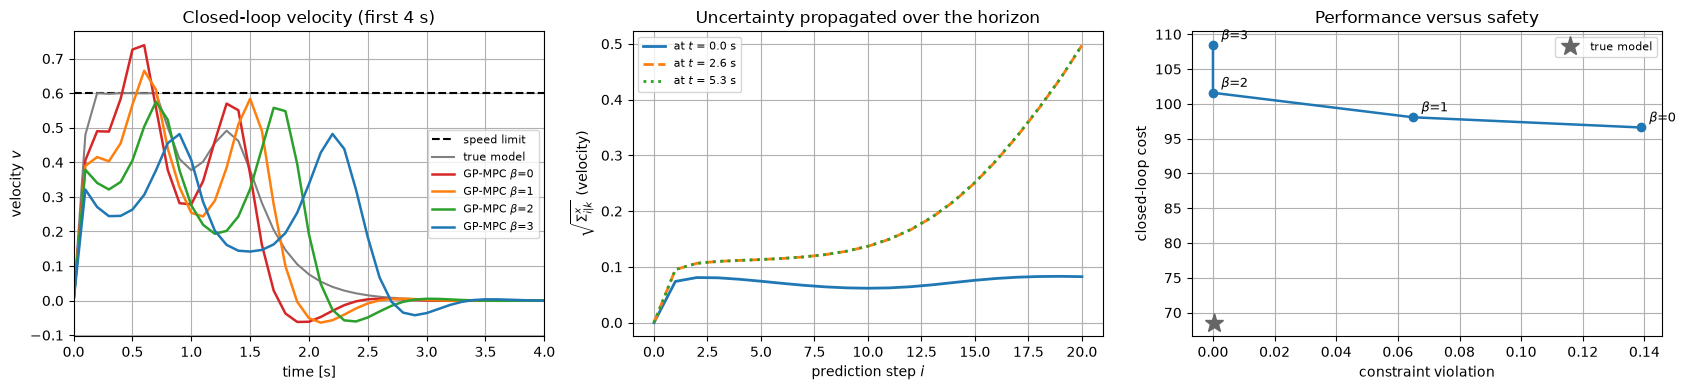

In [7]:
t = np.arange(len(res_true['states'])) / freq

_, axes = plt.subplots(1, 3, figsize=(17, 4))

# Closed-loop velocity against the speed limit
axes[0].axhline(v_max, color='k', linestyle='--', linewidth=1.5, label='speed limit')
axes[0].plot(t, res_true['states'][:, 1], color='0.5', linewidth=1.5, label='true model')
for b, c in zip(betas, ['tab:red', 'tab:orange', 'tab:green', 'tab:blue']):
    axes[0].plot(t, res_gp[b]['states'][:, 1], color=c, linewidth=1.8, label=rf'GP-MPC $\beta$={b:.0f}')
axes[0].set_xlim(0, 4)
axes[0].set_xlabel('time [s]'); axes[0].set_ylabel('velocity $v$'); axes[0].grid(True)
axes[0].legend(fontsize=8); axes[0].set_title('Closed-loop velocity (first 4 s)')

# Uncertainty growth along the prediction horizon
sig = res_gp[2.0]['sigma']
for k, style in ((0, '-'), (len(sig)//3, '--'), (2*len(sig)//3, ':')):
    axes[1].plot(np.arange(N + 1), np.sqrt(sig[k][:, 1]), style, linewidth=2,
                 label=f'at $t$ = {k/freq:.1f} s')
axes[1].set_xlabel('prediction step $i$'); axes[1].set_ylabel(r'$\sqrt{\Sigma^x_{i|k}}$ (velocity)')
axes[1].grid(True); axes[1].legend(fontsize=8)
axes[1].set_title('Uncertainty propagated over the horizon')

# Performance / safety trade-off
axes[2].plot([res_gp[b]['violation'] for b in betas], [res_gp[b]['cost'] for b in betas],
             'o-', color='tab:blue', linewidth=1.8)
for b in betas:
    axes[2].annotate(rf'$\beta$={b:.0f}', (res_gp[b]['violation'], res_gp[b]['cost']),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[2].plot(res_true['violation'], res_true['cost'], '*', color='0.4', markersize=14, label='true model')
axes[2].set_xlabel('constraint violation'); axes[2].set_ylabel('closed-loop cost')
axes[2].grid(True); axes[2].legend(fontsize=8)
axes[2].set_title('Performance versus safety')

plt.tight_layout(); plt.show()

#### **Results Analysis**

**Trusting the learned mean is not safe.** At $\beta = 0$ the controller plans against the GP posterior mean, which reverts towards its prior inside the unexplored gap and so understates the terrain the car actually meets. The closed-loop velocity reaches `0.739` against a limit of `0.6`, a violation of `0.139` sustained over two sampling instants. The model error did not stay in the model: it became a constraint violation.

**Tightening converts uncertainty into safety, at a price.** As $\beta$ increases the violation shrinks and the closed-loop cost rises monotonically: `0.139` at cost `96.6`, then `0.065` at `98.1`, then zero at `101.6`, then zero at `108.4`. The constraint becomes satisfied between $\beta = 1$ and $\beta = 2$, and the cost of buying that safety is about `5%` over the certainty-equivalent controller. Going on to $\beta = 3$ costs a further `7%` and buys nothing, since the constraint was already satisfied. This curve, not any single run, is the design object: the confidence level is a knob with a measurable price, and the price of the *first* useful amount of safety is small.

**Uncertainty accumulates along the horizon.** The middle panel shows $\sqrt{\Sigma^x_{i|k}}$ for the velocity growing from zero at the measured state to about `0.085` at the end of the horizon early in the run, and to about `0.5` once the predicted trajectory crosses the data gap. A model that is accurate one step ahead can still produce a wide distribution twenty steps out, and it is the far end of the horizon that sets how hard the constraints must be tightened.

**The tightening sometimes asks for more room than exists.** The `sat.` column counts how often the requested margin exceeded the available half-width and was capped: `64` times at $\beta = 1$, rising to `557` at $\beta = 3$, out of $80 \times 20 = 1600$ tightened constraints. Where the predicted uncertainty approaches the size of the constraint set itself, the nominal confidence level is simply not attainable, and the achievable $\beta$ is limited by the horizon length. Reporting this is preferable to clipping it silently, because it distinguishes "this controller is conservative" from "this confidence level was never delivered".

**The learned model still tracks poorly.** Every GP-MPC run ends `0.28` short of the target, against `0.14` for the true model. This is the mean model failing, not the uncertainty machinery: the GP has no information in the gap and its mean flattens there, so the car settles where it believes the terrain is level. Uncertainty quantification makes the controller *safe* despite a poor model; it does not make the model good.


<br>

----

#### **Example 1.2: When the Uncertainty Estimate Is Miscalibrated**

The previous example tuned the GP hyperparameters on the data. In practice they are often fixed offline, because re-optimizing them online is expensive. We now repeat the experiment with a GP that uses the same data and the same kernel, but hyperparameters chosen without inspecting the data: a lengthscale of $\ell = 0.5$, about an eighth of the domain, and $\sigma_f = 0.01$, of the order of the terrain height.

The mean of this model is visibly worse, but that is not the point. The point is what it reports about its own reliability, and what the constraint tightening then does with that report.


In [8]:
# Same data, same kernel, hyperparameters chosen without looking at the data
model_gp_untuned = Identifier_GP(lengthscale=0.5, signal_std=0.01, noise_std=sigma_meas)
model_gp_untuned.fit(p_train, h_train)
h_un, var_un, dvar_un = construct_gp_casadi_expression(model_gp_untuned)

print(f"slope std inside the gap:  tuned {np.sqrt(float(sigma2_dh_gp(0.0))):.4f}   "
      f"untuned {np.sqrt(float(dvar_un(0.0))):.4f}   "
      f"(the untuned model claims {np.sqrt(float(sigma2_dh_gp(0.0)))/np.sqrt(float(dvar_un(0.0))):.0f}x less uncertainty)\n")

res_un = {}
for b in (2.0, 3.0):
    env_u, dyn_u = make_learned_env(h_un, var_un, dvar_un)
    res_un[b] = run_closed_loop(env_u, dyn_u, b, f"GPMPCun_beta{int(b)}")

report([(f"GP-MPC tuned,   beta = {b:.0f}", res_gp[b]) for b in (2.0, 3.0)] +
       [(f"GP-MPC UNTUNED, beta = {b:.0f}", res_un[b]) for b in (2.0, 3.0)])

slope std inside the gap:  tuned 0.0970   untuned 0.0076   (the untuned model claims 13x less uncertainty)

field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.


/var/folders/f3/gm0kzm7s32j50ml2fczt0z0c0000gn/T/ipykernel_80811/1282891291.py:85: DeprecationWarning:  The `json_file` argument is deprecated in v0.5.6 and will be removed in a future release. Set AcadosOcp.code_gen_options.json_file instead.
  self.solver = AcadosOcpSolver(ocp, json_file=f"{self.name}.json", verbose=False)


Simulation finished, will start plotting
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.


/var/folders/f3/gm0kzm7s32j50ml2fczt0z0c0000gn/T/ipykernel_80811/1282891291.py:85: DeprecationWarning:  The `json_file` argument is deprecated in v0.5.6 and will be removed in a future release. Set AcadosOcp.code_gen_options.json_file instead.
  self.solver = AcadosOcpSolver(ocp, json_file=f"{self.name}.json", verbose=False)


Simulation finished, will start plotting
controller                         peak v  violation  steps>lim     cost  final err   sat.
------------------------------------------------------------------------------------------
GP-MPC tuned,   beta = 2           0.5754     0.0000          0    101.6     0.2817    395
GP-MPC tuned,   beta = 3           0.4821     0.0000          0    108.4     0.2817    557
GP-MPC UNTUNED, beta = 2           0.7022     0.1022          2    100.2     0.2679      0
GP-MPC UNTUNED, beta = 3           0.6840     0.0840          3    100.5     0.2679      0
------------------------------------------------------------------------------------------
speed limit v_max = 0.6


#### **Results Analysis**

**A miscalibrated variance cannot be repaired by tightening.** The untuned GP reports a slope standard deviation of about `0.008` inside the gap where the tuned model reports `0.097`: it claims roughly thirteen times less uncertainty than it has. The tightening is computed faithfully from that number, so it is thirteen times too small. At $\beta = 2$ the closed loop violates the speed limit by `0.102`, and at $\beta = 3$ it still violates by `0.084`. Raising $\beta$ moves the margin only slightly because the margin was computed from the wrong quantity, and note that the untuned controller never once saturates its tightening: it has plenty of room and simply does not ask for it.

Compare the two rows at $\beta = 2$. The tuned model satisfies the constraint at a cost of `101.6`; the untuned model violates it at a cost of `100.2`. The untuned controller looks marginally cheaper precisely because it is buying no safety, which is the trade the numbers would suggest if one ranked controllers by cost alone.

This is the closed-loop consequence of the misspecification studied in Chapter 6.2. A model whose predictive variance does not reflect its actual error reports a confident bound, the controller tightens by that bound, and the constraint is still violated. The failure is silent from inside the loop: the optimizer converges, and the tightened constraints are satisfied by the *predicted* trajectory. Only the real system disagrees.

The practical consequence is that the confidence level and the calibration of the model are not interchangeable knobs. $\beta$ trades performance for margin **given** a trustworthy variance. It cannot compensate for a variance that is wrong, and raising it in response to observed violations hides the real problem while paying for conservatism.


<blockquote style="
    padding: 18px 20px;
    margin: 1.2em 0;
    background: rgba(56, 139, 253, 0.12);      
    border-left: 4px solid rgba(56, 139, 253, 0.85);
    border-radius: 6px;
    color: inherit !important;                  
">

##### **Takeaway:**

- A learned probabilistic model predicts **one step**; a predictive controller needs the uncertainty **propagated over the horizon**, and the far end of the horizon is what sets the required margin.

- What propagates is the uncertainty of the quantity that actually enters the dynamics. Here that is the terrain **slope** $\mathrm{Var}[h'(p)]$, not the height $\mathrm{Var}[h(p)]$; the two are different objects and one cannot be derived from the other.

- **Constraint tightening turns uncertainty into safety at a measurable cost.** The confidence level $\beta$ traces out a performance-versus-safety curve, and choosing a point on that curve is the design decision.

- **Tightening is only as good as the variance driving it.** A model that understates its uncertainty produces a confident bound, a satisfied prediction, and a violated constraint. Calibration must be established before the variance is trusted, and $\beta$ is not a substitute for it.

</blockquote>
